<a href="https://colab.research.google.com/gist/igorzeck/fc6b0b6728fcf8e32c445b15880b1727/grafos_cidades_similares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Similaridade de cidades brasileiras

- **Fonte (IDH)**: https://www.undp.org/pt/brazil/idhm-municipios-2010
- **Demais**: IBGE

In [1]:
!pip install Igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 63.2 MB/s eta 0:00:0000:0100:01


## Setup

In [2]:
# Importação das bibliotecas
from igraph import Graph
from igraph import plot
import pandas as pd
import numpy as np
# Para o heatmap usa o seaborn
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('municipios_brasil.xlsx', index_col="municipio_id")
df

FileNotFoundError: [Errno 2] No such file or directory: '../municipios_brasil.xlsx'

## Correlação entre municípios

In [79]:
mat_corr = df.drop(columns=['municipio_nome']).T.corr()
mat_corr

municipio_id,3458807,4205407,3205309,5300108,3506003,5208707,3304557,3552205,3106200,5103403,...,3518800,2204709,1702208,2606408,3120003,1600105,3548500,4204251,4106902,5103007
municipio_id,,,,,,,,,,,,,,,,,,,,,
3458807,1.000000,0.751356,0.841153,0.717714,0.769892,0.708909,0.694957,0.753307,0.702342,0.727464,...,0.723919,0.134545,0.603141,0.751652,-0.122389,0.704407,0.791947,0.567749,0.711722,0.523224
4205407,0.751356,1.000000,0.988669,0.998592,0.999472,0.998016,0.996495,0.999951,0.997344,0.999352,...,0.999083,0.118427,0.726146,0.976785,-0.428744,0.997638,0.997915,-0.103324,0.998183,-0.162588
3205309,0.841153,0.988669,1.000000,0.979563,0.992702,0.977268,0.972717,0.988896,0.975151,0.982858,...,0.981469,0.145606,0.743464,0.973634,-0.363122,0.976241,0.996295,0.046884,0.977931,-0.012639
5300108,0.717714,0.998592,0.979563,1.000000,0.996352,0.999880,0.999483,0.998577,0.999751,0.999577,...,0.999945,0.095626,0.707581,0.969957,-0.459608,0.999501,0.993176,-0.154986,0.999958,-0.213186
3506003,0.769892,0.999472,0.992702,0.996352,1.000000,0.995549,0.993343,0.999366,0.994544,0.997901,...,0.997182,0.135438,0.738655,0.980279,-0.406865,0.995235,0.999361,-0.072449,0.995742,-0.132453
5208707,0.708909,0.998016,0.977268,0.999880,0.995549,1.000000,0.999775,0.997880,0.999947,0.999506,...,0.999762,0.103470,0.712107,0.970940,-0.455650,0.999847,0.991873,-0.165728,0.999975,-0.224343
3304557,0.694957,0.996495,0.972717,0.999483,0.993343,0.999775,1.000000,0.996379,0.999940,0.998622,...,0.999145,0.093601,0.703562,0.967141,-0.468047,0.999609,0.989037,-0.186081,0.999720,-0.244179
3552205,0.753307,0.999951,0.988896,0.998577,0.999366,0.997880,0.996379,1.000000,0.997223,0.999139,...,0.999042,0.109309,0.719956,0.974819,-0.435821,0.997329,0.997972,-0.102077,0.998113,-0.160863
3106200,0.702342,0.997344,0.975151,0.999751,0.994544,0.999947,0.999940,0.997223,1.000000,0.999133,...,0.999526,0.098256,0.707720,0.969071,-0.462009,0.999779,0.990574,-0.175465,0.999911,-0.233811


## Heatmap das correlações

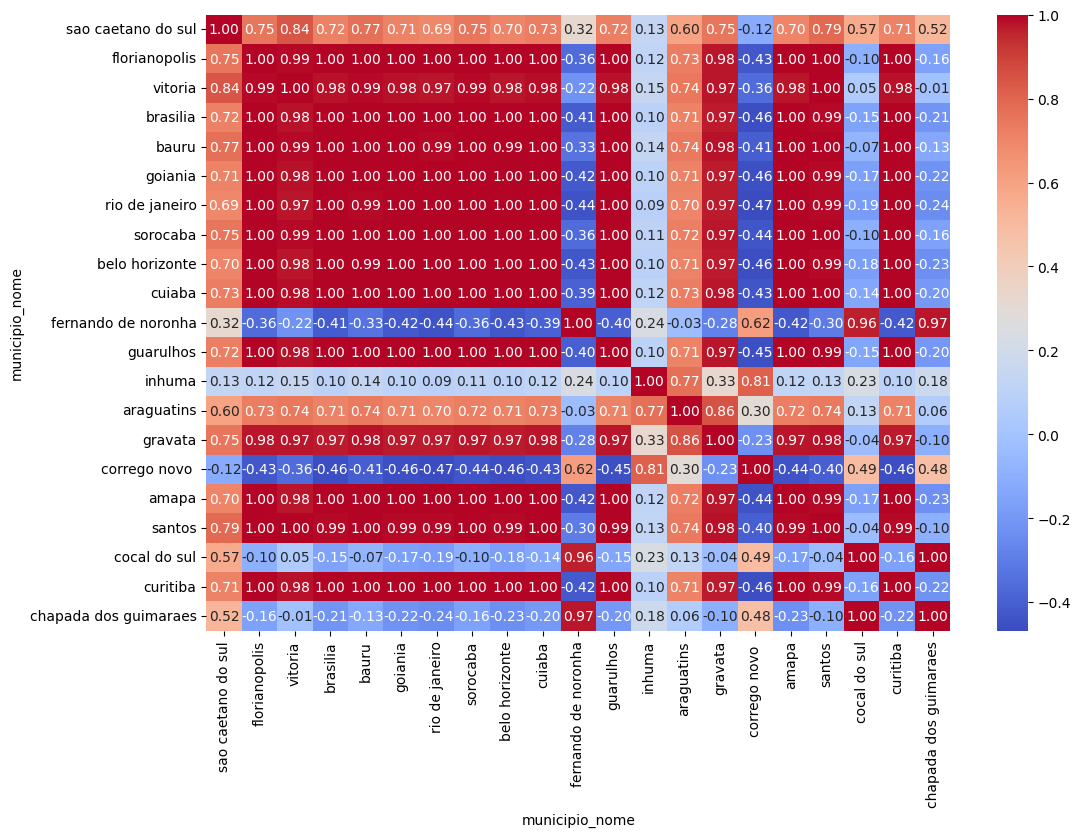

In [80]:
mat_corr_nome = df.reset_index().set_index('municipio_nome').drop(columns=['municipio_id']).T.corr()
mat_corr_nome

plt.figure(figsize=(12, 8))
sns.heatmap(mat_corr_nome, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

## Peso por correlação

Pega as cidades mais semelhantes entre si

Note que utiliza o id dos municipios porque teoricamente nome poderia repetir

In [81]:
# Olha o valor absoluto da correlação
# mat_corr_abs = mat_corr.abs().copy()
# Acho melhor olhar o valor não absoluto na realidade

# Exclue diagonal principal (tem auto-correlação de 1.0 lá!)
np.fill_diagonal(mat_corr.values, np.nan)

def get_dois_mais_simi(row):
    linha_ord = row.dropna().sort_values(ascending=False)

    first_id, first_val = np.nan, np.nan
    second_id, second_val = np.nan, np.nan

    if len(linha_ord) >= 1:
        first_id, first_val = linha_ord.index[0], linha_ord.iloc[0]
    if len(linha_ord) >= 2:
        second_id, second_val = linha_ord.index[1], linha_ord.iloc[1]

    return first_id, first_val, second_id, second_val

# Aplica a função coluna a coluna
top_dois_corr = mat_corr.apply(get_dois_mais_simi, axis=1)

df_result = pd.DataFrame(top_dois_corr.tolist(),
                         index=mat_corr.index,
                         columns=['primeiro_municipio_id', 'primeiro_forca_corr',
                                  'segundo_municipio_id', 'segundo_forca_corr'])

df_result_ord = df_result.sort_values(by='primeiro_forca_corr', ascending=False).reset_index()
df_result_ord

,municipio_id,primeiro_municipio_id,primeiro_forca_corr,segundo_municipio_id,segundo_forca_corr
0,5208707,4106902,0.999975,3106200,0.999947
1,4106902,5208707,0.999975,5300108,0.999958
2,5300108,4106902,0.999958,3518800,0.999945
3,4205407,3552205,0.999951,3506003,0.999472
4,3552205,4205407,0.999951,3506003,0.999366
5,3106200,5208707,0.999947,3304557,0.999940
6,3518800,5300108,0.999945,4106902,0.999844
7,3304557,3106200,0.999940,5208707,0.999775
8,1600105,5208707,0.999847,3106200,0.999779
9,5103403,3518800,0.999788,5300108,0.999577


Note que é espelhado, empre vai ter dois redundantes (Cidade X -> Cidade Y e Cidade Y -> Cidade X

In [82]:
# Ids únicos
todos_municipio_ids = pd.concat([
    df_result_ord['municipio_id'],
    df_result_ord['primeiro_municipio_id'],
    df_result_ord['segundo_municipio_id']
]).dropna().unique()

map_id_novoid = {original_id: new_id for new_id, original_id in enumerate(todos_municipio_ids)}

mapa_id_nome = df['municipio_nome'].to_dict()

df_result_ord['municipio_novo_id'] = df_result_ord['municipio_id'].map(map_id_novoid)
df_result_ord['primeiro_municipio_novo_id'] = df_result_ord['primeiro_municipio_id'].map(map_id_novoid)
df_result_ord['segundo_municipio_novo_id'] = df_result_ord['segundo_municipio_id'].map(map_id_novoid)

df_result_ord['municipio_nome'] = df_result_ord['municipio_id'].map(mapa_id_nome)
df_result_ord['primeiro_municipio_nome'] = df_result_ord['primeiro_municipio_id'].map(mapa_id_nome)
df_result_ord['segundo_municipio_nome'] = df_result_ord['segundo_municipio_id'].map(mapa_id_nome)

display(df_result_ord[[ 'municipio_novo_id', 'municipio_nome',
                           'primeiro_municipio_novo_id', 'primeiro_municipio_nome', 'primeiro_forca_corr',
                           'segundo_municipio_novo_id', 'segundo_municipio_nome', 'segundo_forca_corr']])

,municipio_novo_id,municipio_nome,primeiro_municipio_novo_id,primeiro_municipio_nome,primeiro_forca_corr,segundo_municipio_novo_id,segundo_municipio_nome,segundo_forca_corr
0,0,goiania,1,curitiba,0.999975,5,belo horizonte,0.999947
1,1,curitiba,0,goiania,0.999975,2,brasilia,0.999958
2,2,brasilia,1,curitiba,0.999958,6,guarulhos,0.999945
3,3,florianopolis,4,sorocaba,0.999951,10,bauru,0.999472
4,4,sorocaba,3,florianopolis,0.999951,10,bauru,0.999366
5,5,belo horizonte,0,goiania,0.999947,7,rio de janeiro,0.999940
6,6,guarulhos,2,brasilia,0.999945,1,curitiba,0.999844
7,7,rio de janeiro,5,belo horizonte,0.999940,0,goiania,0.999775
8,8,amapa,0,goiania,0.999847,5,belo horizonte,0.999779
9,9,cuiaba,6,guarulhos,0.999788,2,brasilia,0.999577


In [84]:
id_edges = [tuple([int(v_el) for v_el in v]) for v in df_result_ord[['municipio_novo_id', 'primeiro_municipio_novo_id']].values]
id_edges

[(0, 1),
 (1, 0),
 (2, 1),
 (3, 4),
 (4, 3),
 (5, 0),
 (6, 2),
 (7, 5),
 (8, 0),
 (9, 6),
 (10, 3),
 (11, 10),
 (12, 13),
 (13, 12),
 (14, 11),
 (15, 10),
 (16, 13),
 (17, 15),
 (18, 14),
 (19, 20),
 (20, 19)]

In [85]:
nomes_mun = [nome.capitalize() for nome in df_result_ord['municipio_nome'].values]
nomes_mun

['Goiania',
 'Curitiba',
 'Brasilia',
 'Florianopolis',
 'Sorocaba',
 'Belo horizonte',
 'Guarulhos',
 'Rio de janeiro',
 'Amapa',
 'Cuiaba',
 'Bauru',
 'Santos',
 'Cocal do sul',
 'Chapada dos guimaraes',
 'Vitoria',
 'Gravata',
 'Fernando de noronha',
 'Araguatins',
 'Sao caetano do sul',
 'Inhuma',
 'Corrego novo ']

In [86]:
pesos_mun = [float(peso) for peso in df_result_ord['primeiro_forca_corr']]
pesos_mun

[0.9999745675491954,
 0.9999745675491954,
 0.9999582560746294,
 0.9999511894971821,
 0.9999511894971821,
 0.9999472679830619,
 0.9999451303463136,
 0.9999398260794709,
 0.9998470466189835,
 0.9997880669816159,
 0.9994722187246716,
 0.9993613465114584,
 0.9969650485319096,
 0.9969650485319096,
 0.9962946009676845,
 0.9802789200997402,
 0.9724873240803781,
 0.8565741859711804,
 0.8411526514528685,
 0.8132951230760774,
 0.8132951230760774]

## Grafos

In [87]:
# O número de vértices deve ser o total de IDs únicos
# e as arestas são id_edges
grafo = Graph(len(todos_municipio_ids), edges = id_edges, directed = True)

grafo.vs['label'] = nomes_mun

grafo.es['weight'] = pesos_mun

print(grafo)
# Percorrer os vértices para visualizar os rótulos e pesos (agora como atributo de aresta)
for v in grafo.vs:
    print(v)
# Para ver as arestas e seus pesos:
for e in grafo.es:
    print(e)


IGRAPH D-W- 21 21 --
+ attr: label (v), weight (e)
+ edges:
0->1 1->0 2->1 3->4 4->3 5->0 6->2 7->5 8->0 9->6 10->3 11->10 12->13 13->12
14->11 15->10 16->13 17->15 18->14 19->20 20->19
igraph.Vertex(<igraph.Graph object at 0x799262887550>, 0, {'label': 'Goiania'})
igraph.Vertex(<igraph.Graph object at 0x799262887550>, 1, {'label': 'Curitiba'})
igraph.Vertex(<igraph.Graph object at 0x799262887550>, 2, {'label': 'Brasilia'})
igraph.Vertex(<igraph.Graph object at 0x799262887550>, 3, {'label': 'Florianopolis'})
igraph.Vertex(<igraph.Graph object at 0x799262887550>, 4, {'label': 'Sorocaba'})
igraph.Vertex(<igraph.Graph object at 0x799262887550>, 5, {'label': 'Belo horizonte'})
igraph.Vertex(<igraph.Graph object at 0x799262887550>, 6, {'label': 'Guarulhos'})
igraph.Vertex(<igraph.Graph object at 0x799262887550>, 7, {'label': 'Rio de janeiro'})
igraph.Vertex(<igraph.Graph object at 0x799262887550>, 8, {'label': 'Amapa'})
igraph.Vertex(<igraph.Graph object at 0x799262887550>, 9, {'label': 'Cu

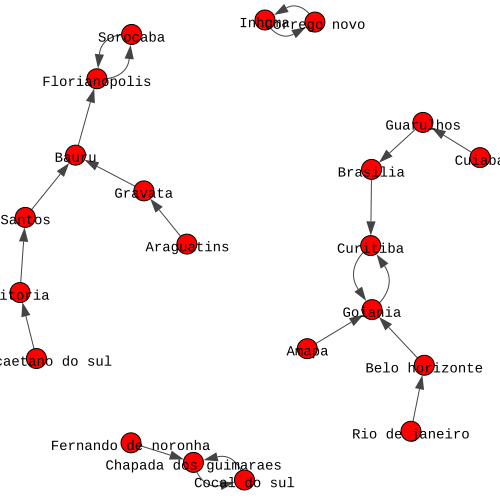

In [89]:
p = plot(grafo, bbox=(0,0,500,500))
p.save('cidades_similares.png')
p

Loucura esse grafo.

Note que várias capitais estão ilhadas juntas!